In [2]:
from google.colab import files

uploaded = files.upload()

filenames = list(uploaded.keys())

print("Uploaded files:")
for i, name in enumerate(filenames):
    print(i, ":", name)

Saving reference.jpg to reference.jpg
Saving input.webp to input (1).webp
Uploaded files:
0 : reference.jpg
1 : input (1).webp


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
input_img = cv2.imread(filenames[0], cv2.IMREAD_GRAYSCALE)
reference_img = cv2.imread(filenames[1], cv2.IMREAD_GRAYSCALE)

if input_img is None or reference_img is None:
    print("Error loading images")
else:
    print("Input image size:", input_img.shape)
    print("Reference image size:", reference_img.shape)

Input image size: (360, 720)
Reference image size: (534, 800)


In [6]:
def histogram_matching(source, reference):

    # Calculate histograms
    source_hist = np.bincount(source.ravel(), minlength=256)
    reference_hist = np.bincount(reference.ravel(), minlength=256)

    # Calculate CDFs
    source_cdf = np.cumsum(source_hist)
    reference_cdf = np.cumsum(reference_hist)

    # Normalize CDFs
    source_cdf = source_cdf / source_cdf[-1]
    reference_cdf = reference_cdf / reference_cdf[-1]

    # Create mapping
    mapping = np.zeros(256, dtype=np.uint8)

    for source_pixel in range(256):

        # Find reference intensity having closest CDF
        difference = np.abs(reference_cdf - source_cdf[source_pixel])
        mapping[source_pixel] = np.argmin(difference)

    # Apply mapping
    matched_img = mapping[source]

    return matched_img


matched_img = histogram_matching(input_img, reference_img)

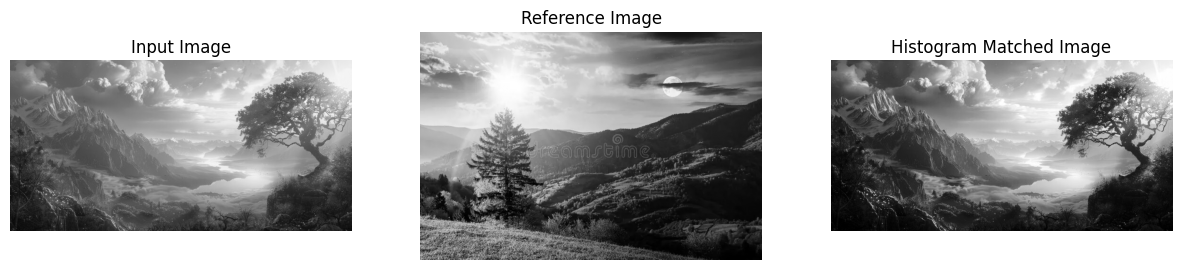

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(reference_img, cmap='gray')
plt.title("Reference Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(matched_img, cmap='gray')
plt.title("Histogram Matched Image")
plt.axis("off")

plt.show()

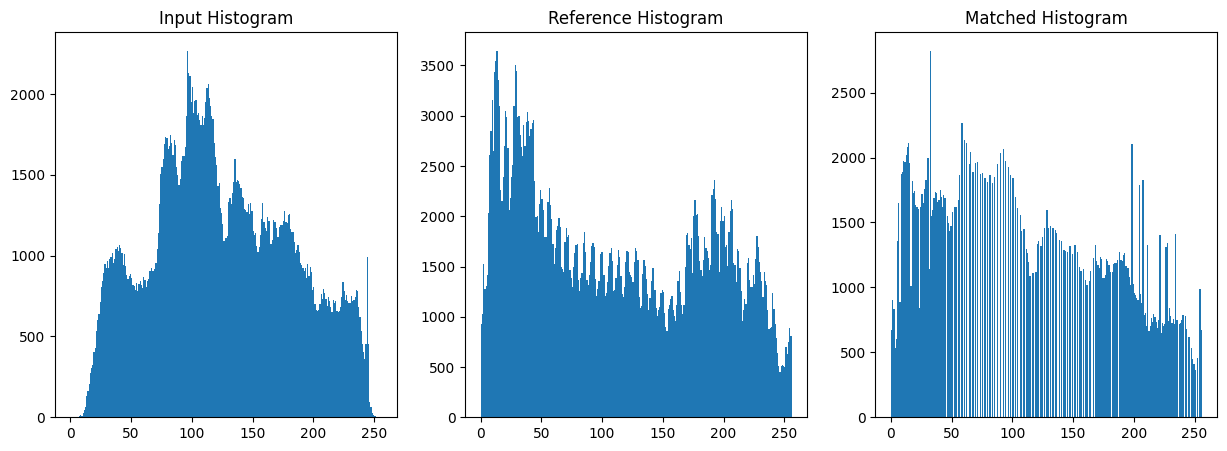

In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(input_img.ravel(), bins=256, range=[0, 256])
plt.title("Input Histogram")

plt.subplot(1, 3, 2)
plt.hist(reference_img.ravel(), bins=256, range=[0, 256])
plt.title("Reference Histogram")

plt.subplot(1, 3, 3)
plt.hist(matched_img.ravel(), bins=256, range=[0, 256])
plt.title("Matched Histogram")

plt.show()